In [1]:
# R1-A2-S4 Redes Neuronales II
# Autor: Bryan Felipe Roa Alvarado
# ---------------------------------------------------------------

In [2]:
"""
Carga de librerías necesarias para manipular y acondicionar los datos.

"""

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
# =============================================================================
# CONSTRUCCIÓN DEL CONJUNTO DE DATOS
# =============================================================================

# La matriz X almacena las variables descriptivas de cada fruta.
#
# Cada fila corresponde a una fruta y cada columna a una de sus propiedades
# (valores ficticios con fines ilustrativos):
#   - Primera columna: masa de la fruta medida en gramos.
#   - Segunda columna: cantidad de azúcar en gramos.
#   - Tercera columna: nivel de maduración, en una escala de 0 a 1.
#
# Las diez primeras observaciones pertenecen a la clase manzana.
# Las diez observaciones restantes pertenecen a la clase banano.

X = np.array([

    # MANZANAS

    [150, 7.5, 0.10], [160, 8.0, 0.15], [145, 7.2, 0.05],
    [170, 8.3, 0.20], [155, 7.8, 0.10], [165, 8.1, 0.15],
    [140, 7.0, 0.05], [175, 8.5, 0.20], [158, 7.9, 0.10],
    [162, 8.2, 0.15],

    # BANANOS

    [120, 18.0, 0.90], [125, 19.0, 0.95], [115, 17.5, 0.85],
    [130, 20.0, 1.00], [118, 18.5, 0.90], [123, 19.5, 0.95],
    [110, 17.0, 0.80], [128, 20.5, 1.00], [121, 18.8, 0.90],
    [126, 19.2, 0.95]

], dtype=float)

# =============================================================================
# DEFINICIÓN DE LAS ETIQUETAS
# =============================================================================

# El vector 'y' guarda la clase a la que pertenece cada fruta del conjunto.
#
#   0 → Manzana
#   1 → Banano
#
# Se asignan 10 etiquetas con valor 0 a las manzanas y 10 etiquetas
# con valor 1 a los bananos.
#
# El método reshape(-1, 1) reorganiza el arreglo en una matriz con una
# única columna, formato requerido por varios algoritmos de scikit-learn.
y = np.array([0]*10 + [1]*10).reshape(-1, 1)

print("X:", X.shape)
print("y:", y.shape)

X: (20, 3)
y: (20, 1)


In [4]:
# =============================================================================
# SEPARACIÓN EN ENTRENAMIENTO Y PRUEBA
# =============================================================================

# El conjunto se reparte en dos subconjuntos: 80% para entrenamiento y
# 20% para prueba.
# El argumento stratify=y conserva la misma proporción de clases en ambos
# subconjuntos, evitando que alguna clase quede subrepresentada.
# random_state=42 fija una semilla para que la partición sea reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# =============================================================================
# ESTANDARIZACIÓN DE LOS DATOS
# =============================================================================

# Se crea un objeto StandardScaler para centrar y escalar las características.
scaler = StandardScaler()

# fit_transform aprende la media y la desviación estándar del conjunto de
# entrenamiento y, con esos parámetros, transforma X_train.
X_train = scaler.fit_transform(X_train)

# transform aplica al conjunto de prueba los mismos parámetros aprendidos
# en entrenamiento. Así se evita que la información de prueba influya en
# el ajuste del escalador.
X_test = scaler.transform(X_test)

# Comprobación del tamaño de los conjuntos obtenidos tras el escalado.

X_train: (16, 3)
X_test: (4, 3)
y_train: (16, 1)
y_test: (4, 1)


In [5]:
# =============================================================================
# FUNCIONES DE ACTIVACIÓN Y ERROR
# =============================================================================

# La función sigmoide transforma cualquier valor de entrada en un número
# dentro del intervalo (0, 1), por lo que resulta adecuada para interpretar
# la salida del modelo como una probabilidad.

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Esta función mide la diferencia entre las etiquetas verdaderas y las
# probabilidades estimadas por el modelo. Se trata de la entropía cruzada
# binaria, cuyo valor crece a medida que la predicción se aleja del valor real.
#
# El término epsilon (1e-8) se añade para evitar calcular el logaritmo de 0,
# lo cual produciría un error numérico.

def calcular_error(y_real, y_predicha):
    epsilon = 1e-8
    return -np.mean(
        y_real * np.log(y_predicha + epsilon)
        + (1 - y_real) * np.log(1 - y_predicha + epsilon)
    )


In [6]:
# =============================================================================
# INICIALIZACIÓN DE LOS PARÁMETROS
# =============================================================================

# Los pesos y el sesgo se generan de forma aleatoria como punto de partida
# para el proceso de entrenamiento.

np.random.seed(42)
W = np.random.randn(3, 1) * 0.01
b = 0.0

# Se obtiene la salida lineal del modelo y se convierte en probabilidades
# aplicando la función sigmoide.

Z = X_train @ W + b
A = sigmoid(Z)

# Se presentan los valores con los que arranca el modelo.
print("Pesos iniciales:")
print(W)

print("Primeras predicciones:")
print(A[:5])

print("Error inicial:", calcular_error(y_train, A))


Pesos iniciales:
[[ 0.00496714]
 [-0.00138264]
 [ 0.00647689]]
Primeras predicciones:
[[0.50018847]
 [0.50039405]
 [0.49975024]
 [0.49958679]
 [0.50021859]]
Error inicial: 0.6929322941038263


In [7]:
# =============================================================================
# AJUSTE DE LOS PARÁMETROS
# =============================================================================

# Se obtienen los gradientes y se modifican los pesos y el sesgo
# aplicando el algoritmo de descenso del gradiente.

dZ = A - y_train

dW = X_train.T @ dZ / len(X_train)
db = np.mean(dZ)

learning_rate = 0.1
W = W - learning_rate * dW
b = b - learning_rate * db

# Se comprueba el estado de los parámetros tras la actualización.
print("Pesos actualizados:")
print(W)

print("Bias actualizado:", b)


Pesos actualizados:
[[-0.04173251]
 [ 0.0483245 ]
 [ 0.05620925]]
Bias actualizado: -2.4020049838036074e-12


In [8]:
# =============================================================================
# ENTRENAMIENTO DEL MODELO
# =============================================================================

# Se definen los parámetros iniciales, la tasa de aprendizaje y el número
# de épocas que durará el entrenamiento.

np.random.seed(42)
W = np.random.randn(3, 1) * 0.01
b = 0.0
learning_rate = 0.1
epochs = 2000

for epoch in range(epochs):

    # Etapa de propagación hacia adelante: se calcula la salida del modelo.
    Z = X_train @ W + b
    A = sigmoid(Z)

    # Cálculo de la pérdida con las predicciones actuales.
    error = calcular_error(y_train, A)

    # Etapa de propagación hacia atrás: se obtienen los gradientes.
    dZ = A - y_train
    dW = X_train.T @ dZ / len(X_train)
    db = np.mean(dZ)

    # Ajuste de los parámetros aplicando descenso del gradiente.
    W = W - learning_rate * dW
    b = b - learning_rate * db

    # Cada 400 épocas se muestra el avance del error para monitorear
    # la convergencia del modelo.
    if epoch % 400 == 0:
        print("Época:", epoch, "- Error:", round(error, 4))



Época: 0 - Error: 0.6929
Época: 400 - Error: 0.0093
Época: 800 - Error: 0.0046
Época: 1200 - Error: 0.0031
Época: 1600 - Error: 0.0023


In [9]:
# =============================================================================
# EVALUACIÓN DEL MODELO
# =============================================================================

# Se calculan las probabilidades para el conjunto de prueba y, a partir de
# un umbral de 0.5, se convierten en etiquetas de clase. Después se obtiene
# la exactitud (accuracy) del modelo comparando las predicciones con las
# respuestas reales.

probabilidades = sigmoid(X_test @ W + b)
predicciones = (probabilidades >= 0.5).astype(int)
accuracy = np.mean(predicciones == y_test)

print("Probabilidades:")
print(probabilidades)

print("Predicciones:")
print(predicciones)

print("Respuestas correctas:")
print(y_test)

print("Accuracy:", accuracy)


Probabilidades:
[[5.57638046e-03]
 [8.91035971e-04]
 [9.97758298e-01]
 [9.97877530e-01]]
Predicciones:
[[0]
 [0]
 [1]
 [1]]
Respuestas correctas:
[[0]
 [0]
 [1]
 [1]]
Accuracy: 1.0


In [10]:
# =============================================================================
# PREDICCIONES Y CLASIFICACIÓN DE UNA NUEVA FRUTA
# =============================================================================

# Se contrastan las estimaciones del modelo con las etiquetas verdaderas
# del conjunto de prueba.

for i in range(len(predicciones)):
    predicha = "MANZANA" if predicciones[i][0] == 0 else "BANANO"
    real = "MANZANA" if y_test[i][0] == 0 else "BANANO"
    print("Fruta", i + 1, "| Predicción:", predicha, "| Real:", real)


# Se genera una observación nueva y se escala con el scaler que fue
# ajustado previamente usando los datos de entrenamiento.

fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)

# Se obtiene la probabilidad y se asigna la categoría resultante.
probabilidad_nueva = sigmoid(fruta_nueva_escalada @ W + b)
resultado = "BANANO" if probabilidad_nueva[0][0] >= 0.5 else "MANZANA"

print("Probabilidad:", probabilidad_nueva[0][0])
print("La red piensa que es:", resultado)


Fruta 1 | Predicción: MANZANA | Real: MANZANA
Fruta 2 | Predicción: MANZANA | Real: MANZANA
Fruta 3 | Predicción: BANANO | Real: BANANO
Fruta 4 | Predicción: BANANO | Real: BANANO
Probabilidad: 0.9980514829516615
La red piensa que es: BANANO


In [11]:
# =============================================================================
# LABORATORIO B: RED MULTICAPA
# =============================================================================

# Se declaran las funciones de activación que empleará la red neuronal.
# La capa oculta usa ReLU, mientras que la capa de salida utiliza Sigmoide.

def relu(z):
    return np.maximum(0, z)

def derivada_relu(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [12]:
# =============================================================================
# INICIALIZACIÓN DE LA RED MULTICAPA
# =============================================================================

# Se generan los pesos y sesgos tanto de la capa oculta como de la capa de
# salida. La arquitectura de la red es: 3 entradas, 4 neuronas en la capa
# oculta y 1 neurona en la capa de salida.

np.random.seed(42)

W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))

W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

# Se comprueban las dimensiones de las matrices de pesos.
print("W1:", W1.shape)
print("W2:", W2.shape)


W1: (3, 4)
W2: (4, 1)


In [13]:
# =============================================================================
# PROPAGACIÓN HACIA ADELANTE
# =============================================================================

# Se obtienen las activaciones de la capa oculta y de la capa de salida
# aplicando las funciones ReLU y Sigmoide, respectivamente.

Z1 = X_train @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

# Se verifican las dimensiones y los primeros valores calculados.
print("Salida de la capa oculta:", A1.shape)
print("Primeras probabilidades:")
print(A2[:5])


Salida de la capa oculta: (16, 4)
Primeras probabilidades:
[[0.42911408]
 [0.41367727]
 [0.35607532]
 [0.34175424]
 [0.27437375]]


In [14]:
# =============================================================================
# RETROPROPAGACIÓN
# =============================================================================

# Se obtienen los gradientes en la capa de salida y se propaga el error
# hacia la capa oculta.

m = len(X_train)

# Gradientes correspondientes a la capa de salida.
dZ2 = A2 - y_train
dW2 = A1.T @ dZ2 / m
db2 = np.mean(dZ2, axis=0, keepdims=True)

# Gradientes correspondientes a la capa oculta.
dA1 = dZ2 @ W2.T
dZ1 = dA1 * derivada_relu(Z1)
dW1 = X_train.T @ dZ1 / m
db1 = np.mean(dZ1, axis=0, keepdims=True)



In [15]:
# =============================================================================
# ENTRENAMIENTO DE LA RED MULTICAPA
# =============================================================================

# Se vuelven a generar los parámetros iniciales y se fijan la tasa de
# aprendizaje y el número de épocas del entrenamiento.

np.random.seed(42)
W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

learning_rate = 0.05
epochs = 3000

for epoch in range(epochs):

    # Propagación hacia adelante.
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # Cálculo del error.
    error = calcular_error(y_train, A2)

    # Retropropagación.
    m = len(X_train)
    dZ2 = A2 - y_train
    dW2 = A1.T @ dZ2 / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * derivada_relu(Z1)
    dW1 = X_train.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

     # Ajuste de pesos y sesgos con descenso del gradiente.
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # Cada 500 épocas se reporta el error para seguir la convergencia.
    if epoch % 500 == 0:
        print("Época:", epoch, "- Error:", round(error, 4))


Época: 0 - Error: 0.9529
Época: 500 - Error: 0.0555
Época: 1000 - Error: 0.0259
Época: 1500 - Error: 0.0166
Época: 2000 - Error: 0.0122
Época: 2500 - Error: 0.0096


In [16]:
# =============================================================================
# EVALUACIÓN DE LA RED MULTICAPA
# =============================================================================

# Se ejecuta la propagación hacia adelante con el conjunto de prueba para
# obtener las probabilidades y medir el desempeño del modelo.

Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)
Z2_test = A1_test @ W2 + b2
probabilidades_test = sigmoid(Z2_test)

# Las probabilidades se transforman en etiquetas de clase aplicando un
# umbral de 0.5.
predicciones_multicapa = (probabilidades_test >= 0.5).astype(int)

# Se calcula la exactitud comparando las predicciones con las etiquetas reales.
accuracy_multicapa = np.mean(predicciones_multicapa == y_test)

print("Probabilidades:")
print(probabilidades_test)

print("Predicciones:")
print(predicciones_multicapa)

print("Accuracy:", accuracy_multicapa)


Probabilidades:
[[1.42439384e-02]
 [2.06256532e-05]
 [9.85087119e-01]
 [9.85087119e-01]]
Predicciones:
[[0]
 [0]
 [1]
 [1]]
Accuracy: 1.0


In [17]:
# =============================================================================
# LABORATORIO C: TENSORFLOW + KERAS
# =============================================================================

# Se replica la misma arquitectura de red multicapa que se construyó
# previamente con NumPy: 3 características de entrada, 4 neuronas en la
# capa oculta y 1 neurona en la capa de salida.

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

modelo = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

# Se presenta un resumen con la estructura del modelo y la cantidad
# de parámetros entrenables.
modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# =============================================================================
# CONFIGURACIÓN DEL MODELO
# =============================================================================

# Se define la forma en que el modelo aprenderá: el optimizador que ajustará
# los parámetros, la función de pérdida que medirá el error y la métrica con
# la que se evaluará su desempeño.

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [19]:
# =============================================================================
# ENTRENAMIENTO DEL MODELO
# =============================================================================

# Se ajusta el modelo con los datos de entrenamiento durante 200 épocas
# y se guarda el registro del proceso en la variable historial.

historial = modelo.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0
)

# Se contrastan la pérdida al inicio y al final del entrenamiento.
print("Error inicial:", historial.history["loss"][0])
print("Error final:", historial.history["loss"][-1])


Error inicial: 0.6169919967651367
Error final: 0.09455614537000656


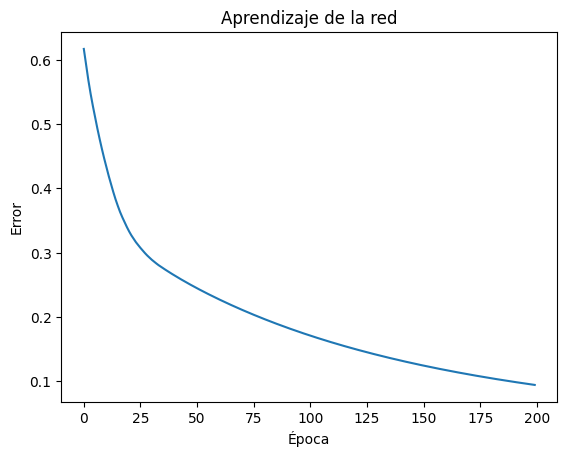

Error en prueba: 0.10013037919998169
Accuracy: 1.0


In [20]:
# =============================================================================
# EVALUACIÓN DEL MODELO
# =============================================================================

# Se representa gráficamente cómo evolucionó la pérdida a lo largo de las
# épocas y, después, se mide el desempeño del modelo con el conjunto de prueba.

import matplotlib.pyplot as plt

plt.plot(historial.history["loss"])
plt.title("Aprendizaje de la red")
plt.xlabel("Época")
plt.ylabel("Error")
plt.show()

# Se obtiene la pérdida y la exactitud del modelo sobre los datos de prueba.
test_loss, test_accuracy = modelo.evaluate(X_test, y_test, verbose=0)

print("Error en prueba:", test_loss)
print("Accuracy:", test_accuracy)


In [21]:
# =============================================================================
# CLASIFICACIÓN DE UNA NUEVA FRUTA
# =============================================================================

# Se prepara una observación nueva y se pasa por el modelo ya entrenado
# para conocer su probabilidad y la clase asignada.

fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)

probabilidad = modelo.predict(fruta_nueva_escalada, verbose=0)
resultado = "BANANO" if probabilidad[0][0] >= 0.5 else "MANZANA"

print("Probabilidad:", probabilidad[0][0])
print("La red piensa que es:", resultado)


Probabilidad: 0.82944584
La red piensa que es: BANANO


In [22]:
# =============================================================================
# CONJUNTO DE DATOS MULTICLASE
# =============================================================================

# Se define un nuevo conjunto de datos que ahora incluye tres tipos de fruta:
# manzanas (0), bananos (1) y naranjas (2).
# Cada observación está descrita por tres características.

X_multi = np.array([
    # MANZANAS - 0
    [150,7.5,.10],[160,8.0,.15],[145,7.2,.05],[170,8.3,.20],[155,7.8,.10],
    [165,8.1,.15],[140,7.0,.05],[175,8.5,.20],[158,7.9,.10],[162,8.2,.15],

    # BANANOS - 1
    [120,18.0,.90],[125,19.0,.95],[115,17.5,.85],[130,20.0,1.00],[118,18.5,.90],
    [123,19.5,.95],[110,17.0,.80],[128,20.5,1.00],[121,18.8,.90],[126,19.2,.95],

    # NARANJAS - 2
    [180,8.0,.35],[190,8.5,.40],[175,7.8,.30],[200,9.0,.45],[185,8.2,.35],
    [195,8.7,.40],[170,7.5,.30],[205,9.2,.45],[188,8.4,.35],[192,8.6,.40]
], dtype=float)

# Se generan las etiquetas que identifican la clase de cada fruta:
# 0 = Manzana, 1 = Banano, 2 = Naranja.

y_multi = np.array([0]*10 + [1]*10 + [2]*10)


In [23]:
# =============================================================================
# DIVISIÓN Y ESTANDARIZACIÓN DE LOS DATOS MULTICLASE
# =============================================================================

# El conjunto se separa en datos de entrenamiento y de prueba, conservando
# la misma proporción de cada clase gracias al parámetro stratify.

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

# Las características se escalan para que el modelo entrene de forma más
# estable y rápida.

scaler_multi = StandardScaler()
X_train_multi = scaler_multi.fit_transform(X_train_multi)
X_test_multi = scaler_multi.transform(X_test_multi)


In [24]:
# =============================================================================
# CONSTRUCCIÓN Y CONFIGURACIÓN DEL MODELO MULTICLASE
# =============================================================================

# Se define una red neuronal capaz de clasificar las tres clases de frutas.
# Su arquitectura consta de 3 entradas, 6 neuronas en la capa oculta y
# 3 neuronas en la capa de salida.

tf.random.set_seed(42)

modelo_multi = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(6, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

# Se prepara el modelo para el entrenamiento estableciendo Adam como
# optimizador y sparse_categorical_crossentropy como función de pérdida.

modelo_multi.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [25]:
# =============================================================================
# ENTRENAMIENTO Y EVALUACIÓN DEL MODELO MULTICLASE
# =============================================================================

# Primero se entrena el modelo con los datos de entrenamiento y luego
# se mide su desempeño con el conjunto de prueba.

historial_multi = modelo_multi.fit(
    X_train_multi,
    y_train_multi,
    epochs=300,
    verbose=0
)

loss_multi, accuracy_multi = modelo_multi.evaluate(
    X_test_multi,
    y_test_multi,
    verbose=0
)

# Se obtienen las probabilidades por clase y se elige como predicción
# aquella con el valor más alto.

probabilidades_multi = modelo_multi.predict(X_test_multi, verbose=0)
predicciones_multi = np.argmax(probabilidades_multi, axis=1)

print("Accuracy:", accuracy_multi)
print("Predicciones:", predicciones_multi)
print("Reales:", y_test_multi)


# =============================================================================
# CLASIFICACIÓN DE UNA NUEVA FRUTA
# =============================================================================

# Se prueba el modelo con una observación nueva para verificar si es capaz
# de reconocer la fruta entre las tres categorías posibles.

nombres_frutas = ["MANZANA", "BANANO", "NARANJA"]

fruta_nueva_multi = np.array([[190, 8.5, 0.38]])
fruta_nueva_multi = scaler_multi.transform(fruta_nueva_multi)

prob = modelo_multi.predict(fruta_nueva_multi, verbose=0)
clase = np.argmax(prob, axis=1)[0]

print("La red piensa que es:", nombres_frutas[clase])


Accuracy: 1.0
Predicciones: [2 1 2 0 1 0]
Reales: [2 1 2 0 1 0]
La red piensa que es: NARANJA


In [26]:
# =============================================================================
# LABORATORIO E: MNIST CON TENSORFLOW + KERAS
# =============================================================================

# Se descarga el conjunto MNIST, empleado para reconocer imágenes de dígitos
# manuscritos y clasificarlas en 10 categorías, una por cada número del 0 al 9.

from tensorflow import keras
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = \
    keras.datasets.mnist.load_data()

# Se comprueban las dimensiones de ambos conjuntos.
print("Entrenamiento:", x_train_mnist.shape, y_train_mnist.shape)
print("Prueba:", x_test_mnist.shape, y_test_mnist.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28) (60000,)
Prueba: (10000, 28, 28) (10000,)


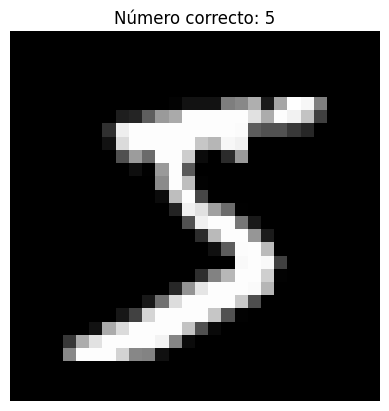

Mínimo: 0.0
Máximo: 1.0


In [27]:
# =============================================================================
# VISUALIZACIÓN Y NORMALIZACIÓN DE LAS IMÁGENES
# =============================================================================

# Se presenta una de las imágenes del conjunto de entrenamiento con su
# etiqueta asociada, como verificación visual de los datos cargados.

import matplotlib.pyplot as plt

plt.imshow(x_train_mnist[0], cmap="gray")
plt.title(f"Número correcto: {y_train_mnist[0]}")
plt.axis("off")
plt.show()

# Los valores de los píxeles se reescalan al intervalo [0, 1] para que
# el proceso de entrenamiento de la red sea más eficiente.

x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

# Se confirma el rango que presentan los valores tras la normalización.
print("Mínimo:", x_train_mnist.min())
print("Máximo:", x_train_mnist.max())


In [28]:
# =============================================================================
# CONSTRUCCIÓN DE LA RED NEURONAL PARA MNIST
# =============================================================================

# Se define una red neuronal densa cuya finalidad es clasificar los dígitos
# del 0 al 9. La entrada corresponde a imágenes de 28x28 píxeles, la capa
# oculta posee 128 neuronas y la capa de salida cuenta con 10 clases.

import tensorflow as tf

tf.random.set_seed(42)

modelo_mnist = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

# Se despliega el resumen con la arquitectura y los parámetros del modelo.
modelo_mnist.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# =============================================================================
# CONFIGURACIÓN Y ENTRENAMIENTO DEL MODELO MNIST
# =============================================================================

# Se prepara el modelo estableciendo Adam como optimizador y una función
# de pérdida apropiada para clasificar las 10 clases.

modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Se entrena el modelo a lo largo de 5 épocas, reservando un 10% de los
# datos de entrenamiento para validar el aprendizaje.

historial_mnist = modelo_mnist.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9213 - loss: 0.2767 - val_accuracy: 0.9627 - val_loss: 0.1282
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9636 - loss: 0.1235 - val_accuracy: 0.9708 - val_loss: 0.0982
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9752 - loss: 0.0834 - val_accuracy: 0.9740 - val_loss: 0.0860
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9825 - loss: 0.0609 - val_accuracy: 0.9738 - val_loss: 0.0832
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9873 - loss: 0.0453 - val_accuracy: 0.9752 - val_loss: 0.0795


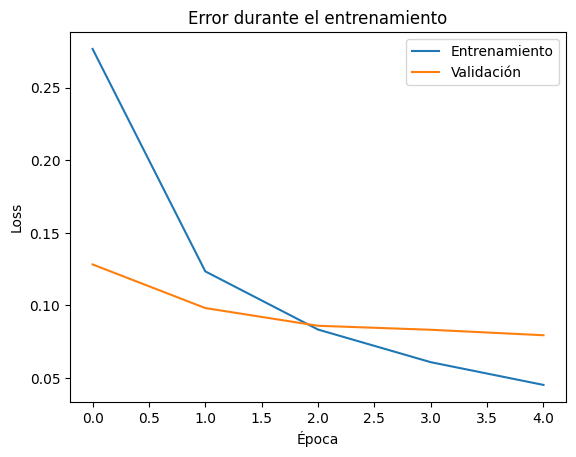

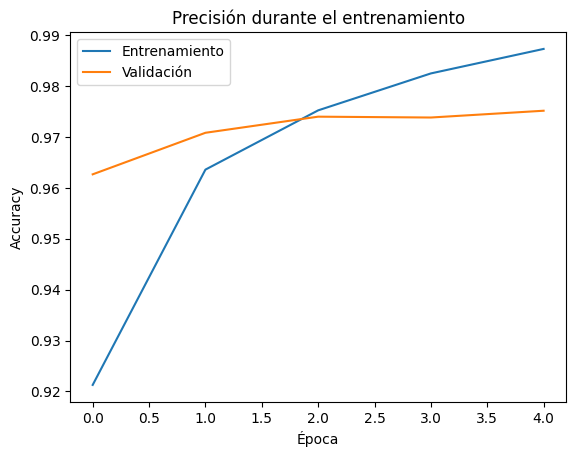

In [30]:
# =============================================================================
# VISUALIZACIÓN DEL ENTRENAMIENTO
# =============================================================================

# Se representan gráficamente la pérdida y la exactitud alcanzadas por el
# modelo a lo largo de las épocas, con el fin de analizar la evolución de
# su aprendizaje.

plt.plot(historial_mnist.history["loss"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_loss"], label="Validación")
plt.title("Error durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(historial_mnist.history["accuracy"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_accuracy"], label="Validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Cantidad de errores: 245


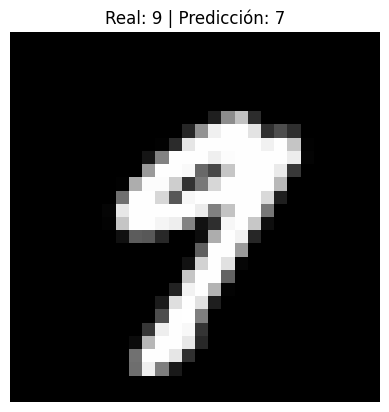

In [31]:
# =============================================================================
# ANÁLISIS DE ERRORES DEL MODELO
# =============================================================================

# Se generan las predicciones sobre el conjunto de prueba y se localizan
# aquellas imágenes que el modelo clasificó de forma equivocada.

predicciones_todas = modelo_mnist.predict(x_test_mnist, verbose=0)
clases_predichas = np.argmax(predicciones_todas, axis=1)
errores = np.where(clases_predichas != y_test_mnist)[0]

print("Cantidad de errores:", len(errores))

# Se presenta una de las imágenes mal clasificadas, contrastando la etiqueta
# verdadera con la predicción obtenida por el modelo.

indice_error = errores[0]

plt.imshow(x_test_mnist[indice_error], cmap="gray")
plt.title(
    f"Real: {y_test_mnist[indice_error]} | "
    f"Predicción: {clases_predichas[indice_error]}"
)
plt.axis("off")
plt.show()


In [32]:
# =============================================================================
# LABORATORIO F: MNIST CON PYTORCH
# =============================================================================

# Se importan las librerías requeridas y se acondiciona el conjunto MNIST
# para manipular imágenes de dígitos manuscritos.

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Se define una transformación que convierte las imágenes en tensores
# y ajusta sus valores.
transform = transforms.ToTensor()

# Se descarga y prepara el conjunto de entrenamiento.
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Se descarga y prepara el conjunto de prueba.
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 21.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 607kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.62MB/s]


In [33]:
# =============================================================================
# PREPARACIÓN DE LOS DATOS
# =============================================================================

# Se construyen los DataLoader, encargados de agrupar los datos en lotes
# tanto para el entrenamiento como para la evaluación del modelo.

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [34]:
# =============================================================================
# CONSTRUCCIÓN DE LA RED NEURONAL
# =============================================================================

# Se implementa una red neuronal destinada a clasificar los dígitos del
# conjunto MNIST. Su arquitectura consta de 784 entradas, 128 neuronas en
# la capa oculta y 10 neuronas en la capa de salida.

class RedMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.capa1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.salida = nn.Linear(128, 10)

    def forward(self, x):
        # Se ejecuta la propagación hacia adelante de los datos.
        x = self.flatten(x)
        x = self.capa1(x)
        x = self.relu(x)
        x = self.salida(x)
        return x


# Se crea una instancia del modelo.
modelo_pytorch = RedMNIST()

print(modelo_pytorch)


RedMNIST(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (capa1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (salida): Linear(in_features=128, out_features=10, bias=True)
)


In [35]:
# =============================================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
# =============================================================================

# Se establecen la función de pérdida y el optimizador que se emplearán
# a lo largo del entrenamiento de la red.

criterio = nn.CrossEntropyLoss()

optimizador = optim.Adam(
    modelo_pytorch.parameters(),
    lr=0.001
)

print("Modelo, criterio y optimizador listos")


Modelo, criterio y optimizador listos


In [36]:
# =============================================================================
# ENTRENAMIENTO DE LA RED CON PYTORCH
# =============================================================================

# Se entrena el modelo a lo largo de varias épocas siguiendo el ciclo
# de entrenamiento explícito que propone PyTorch.

epochs = 3

for epoch in range(epochs):
    modelo_pytorch.train()
    error_total = 0

    for imagenes, etiquetas in train_loader:

        # Se reinician los gradientes acumulados en la iteración previa.
        optimizador.zero_grad()

        # Propagación hacia adelante.
        salidas = modelo_pytorch(imagenes)

        # Cálculo del error.
        error = criterio(salidas, etiquetas)

        # Retropropagación.
        error.backward()

        # Actualización de los pesos.
        optimizador.step()

        error_total += error.item()

    # Se calcula el error promedio de la época.
    promedio_error = error_total / len(train_loader)

    print(
        "Época:", epoch + 1,
        "- Error:", round(promedio_error, 4)
    )


Época: 1 - Error: 0.351
Época: 2 - Error: 0.1565
Época: 3 - Error: 0.1066


In [37]:
# =============================================================================
# EVALUACIÓN DEL MODELO
# =============================================================================

# Se mide el desempeño del modelo sobre el conjunto de prueba y se obtiene
# la exactitud de sus predicciones.

modelo_pytorch.eval()
correctas = 0
total = 0

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        salidas = modelo_pytorch(imagenes)
        _, predicciones = torch.max(salidas, 1)

        total += etiquetas.size(0)
        correctas += (predicciones == etiquetas).sum().item()

# Se determina la exactitud final alcanzada por el modelo.
accuracy_pytorch = correctas / total

print("Accuracy en prueba:", accuracy_pytorch)


Accuracy en prueba: 0.97


Número real: 7
Número predicho: 7


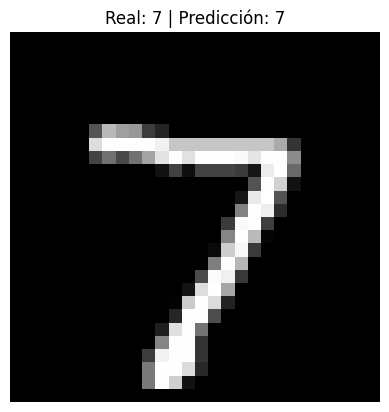

In [38]:
# =============================================================================
# PREDICCIÓN DE UNA IMAGEN
# =============================================================================

# Se toma una imagen del conjunto de prueba y se pasa por el modelo para
# conocer qué dígito identifica.

imagen, etiqueta_real = test_dataset[0]
entrada = imagen.unsqueeze(0)

modelo_pytorch.eval()

with torch.no_grad():
    salida = modelo_pytorch(entrada)
    prediccion = torch.argmax(salida, dim=1).item()

print("Número real:", etiqueta_real)
print("Número predicho:", prediccion)

# Se visualiza la imagen junto con su etiqueta real y la predicción obtenida.
plt.imshow(imagen.squeeze(), cmap="gray")
plt.title(f"Real: {etiqueta_real} | Predicción: {prediccion}")
plt.axis("off")
plt.show()
